# GSOM station files

The Global Summary of the Month is NOAA NCEI's set of monthly station summaries
derived from GHCN-Daily: means, extremes, totals, and day counts for tens of
thousands of stations. Besides its query service, NCEI publishes one static CSV
per station holding that station's whole monthly record, every element, in
metric units. A file is one plain download, which makes it the fast way to get
long records for many stations.

This walkthrough pulls the complete files for two snowbelt airports,
Pittsburgh and Buffalo, and totals their snowfall winter by winter since 1950.
It needs `usdata[pandas]` and matplotlib, and downloads about 1.3 MB.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-29T03:43:03+00:00
usdata 0.32.0; pandas 3.0.6


## Select

The manifest names two GHCN station ids and nothing else. A station file is
always the whole record of every element, so there is no window, box, or
variable to give; months and columns are chosen after opening. `USW00094823`
is Pittsburgh International Airport and `USW00014733` is Buffalo Niagara
International Airport.

In [2]:
print(manifest.read_text())

name: two-snowbelt-records
sources:
  - dataset: noaa:gsom-station-files
    params: {stations: [USW00094823, USW00014733]}



## What arrives

The first pull downloads one file per station, named by its id, and writes
`dataset.lock.json` beside the manifest, pinning each file's checksum
separately. NCEI rewrites a station's file as its summaries change, so a pin
on one station can drift without touching the other.

In [3]:
result = pull(manifest)
for item in result.fetched:
    print(f"{item.asset.id}  {item.provenance.size:,} bytes  {item.provenance.source_url}")
print("Retrieved (UTC):", result.fetched[0].provenance.retrieved_at.isoformat(timespec="seconds"))

USW00014733.csv  688,743 bytes  https://www.ncei.noaa.gov/data/global-summary-of-the-month/access/USW00014733.csv
USW00094823.csv  605,617 bytes  https://www.ncei.noaa.gov/data/global-summary-of-the-month/access/USW00094823.csv
Retrieved (UTC): 2026-09-29T03:43:04+00:00


## Open

`open()` returns a pandas DataFrame, one row per month from the station's first
summarised month to its last. After the station, date, position, elevation,
and name come the elements, each followed by its `_ATTRIBUTES` column. Which
elements appear depends on the station. `SNOW` is the month's snowfall in
millimetres, and a blank means NCEI could not compute it: more than five days
missing or flagged. The attribute is `DaysMissing,Measurement,Quality,Source`,
so its first field counts the days that were missing.

In [4]:
AIRPORTS = {"USW00094823": "Pittsburgh", "USW00014733": "Buffalo"}
frames = {}
for item in result.fetched:
    frame = item.open()
    station = frame["STATION"].iloc[0]
    frames[AIRPORTS[station]] = frame
    print(
        f"{station} {frame['NAME'].iloc[0]}: {len(frame)} months, "
        f"{frame['DATE'].iloc[0]} to {frame['DATE'].iloc[-1]}, {len(frame.columns)} columns"
    )
print("Properties:", result.fetched[0].asset.properties)
frames["Pittsburgh"].set_index("DATE").loc["1997-11":"1998-03", ["SNOW", "SNOW_ATTRIBUTES"]]

USW00014733 BUFFALO NIAGARA INTERNATIONAL AIRPOR, NY US: 1061 months, 1938-05 to 2026-09, 110 columns
USW00094823 PITTSBURGH INTERNATIONAL AIRPORT, PA US: 945 months, 1948-01 to 2026-09, 106 columns
Properties: {'units': 'metric'}


,SNOW,SNOW_ATTRIBUTES
DATE,,
1997-11,64.0,",,,Z"
1997-12,320.0,",,,0"
1998-01,45.0,",,,0"
1998-02,64.0,",,,0"
1998-03,125.0,",,,0"


A winter here is November to March, named by the year it starts, and it
counts only when all five months have a value, so a gap never reads as a snow
drought.

In [5]:
def winter_totals(frame: pd.DataFrame) -> pd.Series:
    """Snowfall per November-March winter, where all five months have a value."""
    months = frame.assign(
        year=frame["DATE"].str[:4].astype(int), month=frame["DATE"].str[5:].astype(int)
    )
    months = months[months["month"].isin([11, 12, 1, 2, 3])]
    winter = months["year"] - (months["month"] <= 3)
    grouped = months.groupby(winter)["SNOW"]
    return grouped.sum()[grouped.count() == 5].loc[1950:2025]


winters = pd.DataFrame({name: winter_totals(frame) / 10 for name, frame in frames.items()})
print(winters.describe().round(0).loc[["count", "mean", "min", "max"]].to_string())

       Buffalo  Pittsburgh
count     76.0        76.0
mean     231.0       106.0
min       91.0        39.0
max      500.0       197.0


## A first look

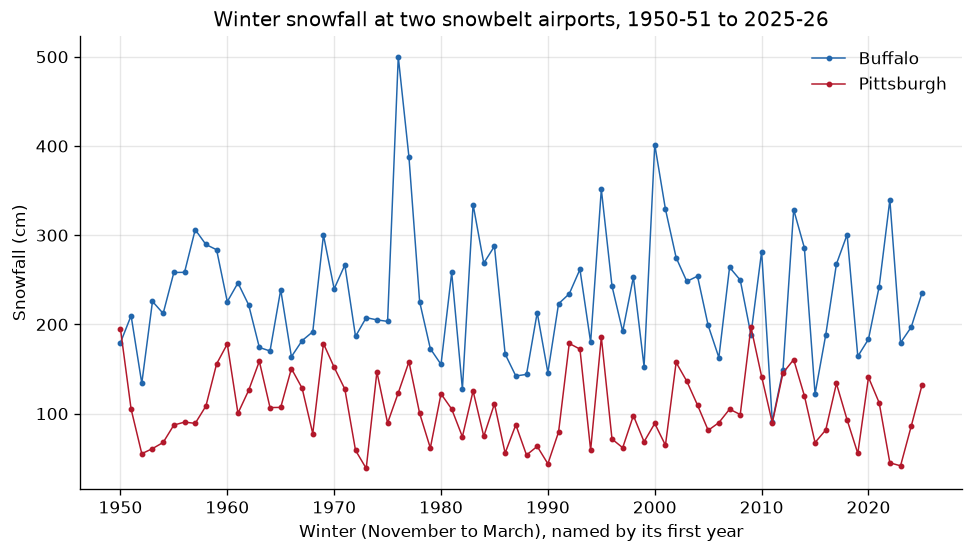

In [6]:
fig, ax = plt.subplots(layout="constrained")
for name, colour in [("Buffalo", "#2166ac"), ("Pittsburgh", "#b2182b")]:
    series = winters[name]
    ax.plot(
        series.index, series, marker="o", markersize=2.5, linewidth=0.9, color=colour, label=name
    )
ax.set_xlabel("Winter (November to March), named by its first year")
ax.set_ylabel("Snowfall (cm)")
ax.set_title("Winter snowfall at two snowbelt airports, 1950-51 to 2025-26")
ax.legend(frameon=False)
plt.show()

In [7]:
for name, series in winters.items():
    top = series.idxmax()
    print(
        f"{name}: snowiest winter {top}-{str(top + 1)[2:]}, "
        f"{series.max():.0f} cm; median {series.median():.0f} cm"
    )

Buffalo: snowiest winter 1976-77, 500 cm; median 225 cm
Pittsburgh: snowiest winter 2009-10, 197 cm; median 100 cm


Buffalo, downwind of Lake Erie, gets roughly twice Pittsburgh's snow in a
typical winter, and its lake-effect seasons swing much further from one year
to the next.

## Pin and cite

`verify` checks both cached files against the lockfile's checksums. The
citation below is what a methods section needs, and `usdata cite dataset.yaml`
prints the same.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:gsom-station-files
  Lawrimore, Jay H.; Ray, Ron; Applequist, Scott; Korzeniewski, Bryant; Menne, Matthew J. (2016): Global Summary of the Month (GSOM), Version 1. NOAA National Centers for Environmental Information. https://doi.org/10.7289/V5QV3JJ5
  homepage: https://www.ncei.noaa.gov/data/global-summary-of-the-month/
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C00946/html
  retrieved: 2026-09-29; 2 checksummed assets (1,294,360 bytes) pinned by usdata 0.32.0
  sources: 1


## What was awkward

- A file holds every element, so two stations' snowfall costs about 1.3 MB of
  mostly other columns; there is no way to ask for `SNOW` alone.
- A station's span is only known after the download: the asset's time is the
  archive's bound from 1763, not the station's own first and last month.
- Winters straddle calendar years, so totalling one takes a few lines of
  date arithmetic, and a blank month has to be treated as missing rather than
  as zero.
- NCEI's `NAME` column is cut at 30 characters ("BUFFALO NIAGARA INTERNATIONAL
  AIRPOR"), so labels come from a lookup of station ids instead.
- The attribute column packs four flags into one comma-separated string, so
  reading the days-missing count means splitting it yourself.